## SubGraphs are important for the multi-agent system 

In [1]:
from langchain_groq import ChatGroq
from langgraph.graph.message import add_messages
from langgraph.types import interrupt, Command
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.checkpoint.memory import MemorySaver
import sqlite3
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.messages import HumanMessage, BaseMessage,  AIMessage
from dotenv import load_dotenv
load_dotenv()
import os

In [28]:
llm = ChatGroq(
    model=os.getenv('model'),
)

GroqError: The api_key client option must be set either by passing api_key to the client or by setting the GROQ_API_KEY environment variable

In [6]:
class SubState(TypedDict):
    input_text : str
    trasnlated_text :str


In [8]:
def trasnlation(state : SubState):
    return {'translated_text' : llm.invoke(f"translate the text into nepali language but using english letters {state['input_text']}")}

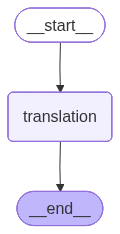

In [11]:
subgraph_build = StateGraph(SubState)

subgraph_build.add_node("translation", trasnlation)
subgraph_build.add_edge(START, "translation")
subgraph_build.add_edge("translation", END)

subgraph = subgraph_build.compile()
subgraph

In [13]:
class ParentState(TypedDict):
    topic : str
    joke_eng : str
    joke_nep : str


In [15]:
def generate(state : ParentState):
    return {'joke_eng' : llm.invoke(f"Write me a joke on the topic {state['topic']}")}

In [23]:
def trasnlation_nep(state : ParentState):
    result = subgraph.invoke({'input_text' : state['joke_eng']})
    return {'joke_nep' : result['trasnlated_text']}

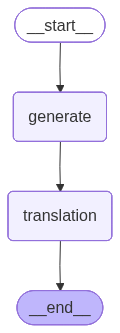

In [27]:
graph = StateGraph(ParentState)

graph.add_node("generate", generate)
graph.add_node("translation", trasnlation_nep)
graph.add_edge(START, "generate")
graph.add_edge("generate", "translation")
graph.add_edge("translation", END)

workflow = graph.compile()
workflow


In [ ]:
workflow.invoke({'topic' : "RNN vs LSTM"})